# Bài Tập 2: Differential Evolution và Cross Entropy Method
**Môn học:** Tối ưu hóa

**Tên sinh viên:** ...

**MSSV:** 23520108

*(Notebook sinh bởi Assistant)*

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from scipy import stats
from IPython.display import display, Markdown, HTML

MSSV = 23520108  # CHÚ Ý: Bạn có thể thay đổi biến này thành MSSV thực tế để nghiệm thu

# Hàm trả về seed dựa trên index
def get_seed(i):
    return MSSV + i


In [6]:
# 2. Cài đặt các hàm mục tiêu (Objective Functions)
def sphere(x):
    return np.sum(x**2)

def rastrigin(x):
    return 10 * len(x) + np.sum(x**2 - 10 * np.cos(2 * np.pi * x))

def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1]**2)**2.0 + (1 - x[:-1])**2.0)

def ackley(x):
    d = len(x)
    sum_sq = np.sum(x**2)
    sum_cos = np.sum(np.cos(2 * np.pi * x))
    term1 = -20 * np.exp(-0.2 * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + 20 + np.e

def griewank(x):
    sum_sq = np.sum(x**2) / 4000.0
    prod_cos = np.prod(np.cos(x / np.sqrt(np.arange(1, len(x) + 1))))
    return sum_sq - prod_cos + 1.0

# Định nghĩa miền giá trị theo chuẩn
FUNCTIONS = {
    'Sphere': {'func': sphere, 'bound': [-5.12, 5.12], 'opt_val': 0.0},
    'Rastrigin': {'func': rastrigin, 'bound': [-5.12, 5.12], 'opt_val': 0.0},
    'Rosenbrock': {'func': rosenbrock, 'bound': [-5.0, 10.0], 'opt_val': 0.0},
    'Ackley': {'func': ackley, 'bound': [-32.0, 32.0], 'opt_val': 0.0},
    'Griewank': {'func': griewank, 'bound': [-600.0, 600.0], 'opt_val': 0.0}
}


In [7]:
# 3. Cài đặt Differential Evolution (DE)
def differential_evolution(func, bounds, popsize, max_evals, seed, return_history=False, return_pop_history=False):
    np.random.seed(seed)
    d = len(bounds)
    
    # Khởi tạo quần thể
    pop = np.random.uniform(bounds[:, 0], bounds[:, 1], size=(popsize, d))
    fitness = np.apply_along_axis(func, 1, pop)
    evals = popsize
    
    best_idx = np.argmin(fitness)
    best_fit = fitness[best_idx]
    
    F = 0.8
    CR = 0.9
    
    history = [(evals, best_fit)]
    pop_history = [pop.copy()] if return_pop_history else []
    
    while evals < max_evals:
        for i in range(popsize):
            if evals >= max_evals:
                break
                
            # Chọn 3 cá thể ngẫu nhiên khác i
            idxs = [idx for idx in range(popsize) if idx != i]
            a, b, c = pop[np.random.choice(idxs, 3, replace=False)]
            
            # Đột biến vector
            mutant = np.clip(a + F * (b - c), bounds[:, 0], bounds[:, 1])
            cross_points = np.random.rand(d) < CR
            
            # Bắt buộc ít nhất 1 chiều được chọn
            if not np.any(cross_points):
                cross_points[np.random.randint(0, d)] = True
            
            # Lai ghép (trial vector)
            trial = np.where(cross_points, mutant, pop[i])
            
            # Đánh giá fitness
            f_trial = func(trial)
            evals += 1
            
            # Cập nhật kết quả cá thể
            if f_trial < fitness[i]:
                pop[i] = trial
                fitness[i] = f_trial
                if f_trial < best_fit:
                    best_fit = f_trial
                    
        # History ghi nhận sau khi duyệt mỗi mốc (gần như thế hệ)
        if return_history:
            history.append((evals, best_fit))
        if return_pop_history:
            pop_history.append(pop.copy())
            
    if return_history or return_pop_history:
        if return_history and return_pop_history:
            return best_fit, history, pop_history
        elif return_history:
            return best_fit, history
        return best_fit, pop_history
    return best_fit


In [8]:
# 3. Cài đặt Cross Entropy Method (CEM) cải tiến
def cross_entropy_method(func, bounds, popsize, max_evals, seed, return_history=False, return_pop_history=False):
    np.random.seed(seed)
    d = len(bounds)
    num_elites = max(2, int(popsize * 0.2)) # Chọn 20% cá thể tinh hoa
    
    # Khởi tạo mô hình phân phối
    mu = np.random.uniform(bounds[:, 0], bounds[:, 1])
    sigma = (bounds[:, 1] - bounds[:, 0]) / 2.0
    
    evals = 0
    best_fit = np.inf
    
    history = []
    pop_history = []
    
    while evals < max_evals:
        # Trong trường hợp lần gọi gần cuối, chỉ lấy đúng số cá thể để chạm kịch trần max_evals
        current_popsize = min(popsize, max_evals - evals)
        
        # Sinh quần thể từ Gaussian Distribution
        pop = np.random.normal(mu, sigma, size=(current_popsize, d))
        pop = np.clip(pop, bounds[:, 0], bounds[:, 1])
        
        if return_pop_history:
            pop_history.append(pop.copy())
            
        # Đánh giá fitness
        fitness = np.apply_along_axis(func, 1, pop)
        evals += current_popsize
        
        current_best_fit = np.min(fitness)
        if current_best_fit < best_fit:
            best_fit = current_best_fit
            
        if return_history:
            history.append((evals, best_fit))
            
        # Lấy subset Elites
        elite_idxs = np.argsort(fitness)[:min(num_elites, current_popsize)]
        elites = pop[elite_idxs]
        
        # Cập nhật phân phối
        mu = np.mean(elites, axis=0)
        sigma = np.std(elites, axis=0) + 1e-5
        
    if return_history or return_pop_history:
        if return_history and return_pop_history:
            return best_fit, history, pop_history
        elif return_history:
            return best_fit, history
        return best_fit, pop_history
    return best_fit


In [9]:
# 4. Kịch bản thực nghiệm
import pandas as pd
import warnings
warnings.filterwarnings('ignore') # Tránh cảnh báo không cần thiết từ scipy.stats

dims = [2, 10]
popsizes = [8, 16, 32, 64, 128]
num_runs = 10

experiment_results = []
convergence_data = {} 

# Thực hiện vòng lặp thử nghiệm khổng lồ. 
# Nó sẽ chạy mất trung bình khoảng 1-2 phút tùy tốc độ máy.
for func_name, info in FUNCTIONS.items():
    convergence_data[func_name] = {}
    func = info['func']
    for d in dims:
        bounds = np.array([info['bound']] * d)
        max_evals = 2000 if d == 2 else 10000
        convergence_data[func_name][d] = {}
        for N in popsizes:
            de_bests = []
            cem_bests = []
            
            de_histories = []
            cem_histories = []
            
            for i in range(num_runs):
                seed = get_seed(i)
                # Chạy DE
                de_best, de_hist = differential_evolution(func, bounds, N, max_evals, seed, return_history=True)
                de_bests.append(de_best)
                de_histories.append(de_hist)
                
                # Chạy CEM
                cem_best, cem_hist = cross_entropy_method(func, bounds, N, max_evals, seed, return_history=True)
                cem_bests.append(cem_best)
                cem_histories.append(cem_hist)
                
            # Lưu history để sử dụng trong plot_convergence sau
            convergence_data[func_name][d][N] = {
                'DE_hists': de_histories,
                'CEM_hists': cem_histories
            }
                
            de_mean = np.mean(de_bests)
            de_std = np.std(de_bests)
            
            cem_mean = np.mean(cem_bests)
            cem_std = np.std(cem_bests)
            
            # Sử dụng Independent t-test
            t_stat, p_value = stats.ttest_ind(de_bests, cem_bests)
            
            if p_value < 0.05:
                if de_mean < cem_mean:
                    winner = 'DE'
                else:
                    winner = 'CEM'
            else:
                winner = 'Tie'
                
            experiment_results.append({
                'Hàm': func_name,
                'd': d,
                'N': N,
                'DE_Mean': de_mean,
                'DE_Std': de_std,
                'CEM_Mean': cem_mean,
                'CEM_Std': cem_std,
                'Winner': winner
            })

df_results = pd.DataFrame(experiment_results)


In [10]:
# 5. Thống kê và báo cáo (Tóm tắt kết quả theo Markdown)
md_lines = ["| Hàm | N | d | DE_Mean(std) | CEM_Mean(std) | Winner |", "|---|---|---|---|---|---|"]

for _, row in df_results.iterrows():
    de_str = f"{row['DE_Mean']:.4e} ({row['DE_Std']:.4e})"
    cem_str = f"{row['CEM_Mean']:.4e} ({row['CEM_Std']:.4e})"
    
    # Làm nổi bật kết quả chiến thắng bằng in đậm
    if row['Winner'] == 'DE':
        de_str = f"**{de_str}**"
    elif row['Winner'] == 'CEM':
        cem_str = f"**{cem_str}**"

    md_lines.append(f"| {row['Hàm']} | {row['N']} | {row['d']} | {de_str} | {cem_str} | {row['Winner']} |")

display(Markdown("\n".join(md_lines)))


| Hàm | N | d | DE_Mean(std) | CEM_Mean(std) | Winner |
|---|---|---|---|---|---|
| Sphere | 8 | 2 | 1.7604e-05 (3.5208e-05) | 4.4423e+00 (7.1767e+00) | Tie |
| Sphere | 16 | 2 | 2.7551e-23 (6.1902e-23) | 1.5728e-01 (4.5732e-01) | Tie |
| Sphere | 32 | 2 | 7.2151e-12 (7.4977e-12) | 8.8461e-03 (2.6538e-02) | Tie |
| Sphere | 64 | 2 | 7.7963e-07 (1.2222e-06) | 2.7745e-13 (3.7106e-13) | Tie |
| Sphere | 128 | 2 | 3.9121e-04 (2.3345e-04) | **9.9015e-13 (7.5804e-13)** | CEM |
| Sphere | 8 | 10 | **2.2113e-01 (6.0556e-01)** | 5.0028e+01 (1.8211e+01) | DE |
| Sphere | 16 | 10 | **2.1936e-13 (3.0004e-13)** | 1.2517e+01 (4.7887e+00) | DE |
| Sphere | 32 | 10 | **3.7755e-04 (4.5919e-04)** | 5.8077e-01 (5.6599e-01) | DE |
| Sphere | 64 | 10 | 2.1035e-01 (9.4896e-02) | **3.8809e-02 (1.0879e-01)** | CEM |
| Sphere | 128 | 10 | 2.2730e+00 (4.0797e-01) | **7.9406e-10 (1.0793e-10)** | CEM |
| Rastrigin | 8 | 2 | **2.8370e-01 (4.0004e-01)** | 8.0123e+00 (7.0320e+00) | DE |
| Rastrigin | 16 | 2 | **7.1054e-16 (2.1316e-15)** | 1.6654e+00 (1.5499e+00) | DE |
| Rastrigin | 32 | 2 | **9.3576e-03 (1.9727e-02)** | 5.2169e-01 (4.2812e-01) | DE |
| Rastrigin | 64 | 2 | 3.3000e-01 (3.3444e-01) | **5.7901e-02 (1.7370e-01)** | CEM |
| Rastrigin | 128 | 2 | 6.7171e-01 (4.6552e-01) | **1.3918e-01 (2.8972e-01)** | CEM |
| Rastrigin | 8 | 10 | **2.0925e+01 (1.2256e+01)** | 1.0326e+02 (2.3298e+01) | DE |
| Rastrigin | 16 | 10 | **1.0157e+01 (4.9155e+00)** | 6.0186e+01 (2.1106e+01) | DE |
| Rastrigin | 32 | 10 | 4.4595e+01 (3.9514e+00) | **1.5758e+01 (5.9438e+00)** | CEM |
| Rastrigin | 64 | 10 | 5.7391e+01 (6.6711e+00) | **5.4898e+00 (2.7375e+00)** | CEM |
| Rastrigin | 128 | 10 | 6.3312e+01 (9.2635e+00) | **2.0135e+00 (1.2601e+00)** | CEM |
| Rosenbrock | 8 | 2 | **5.1460e-01 (1.3650e+00)** | 4.9098e+00 (5.5773e+00) | DE |
| Rosenbrock | 16 | 2 | **1.0668e-13 (2.8441e-13)** | 2.6865e+00 (3.4429e+00) | DE |
| Rosenbrock | 32 | 2 | **7.4394e-05 (1.7840e-04)** | 3.3805e+00 (4.1750e+00) | DE |
| Rosenbrock | 64 | 2 | 8.7612e-02 (9.3242e-02) | 3.5889e-01 (5.3286e-01) | Tie |
| Rosenbrock | 128 | 2 | 1.0756e-01 (9.1984e-02) | 4.0292e-02 (3.0334e-02) | Tie |
| Rosenbrock | 8 | 10 | **5.4990e+03 (1.6147e+04)** | 5.5712e+05 (4.4155e+05) | DE |
| Rosenbrock | 16 | 10 | **1.5771e+00 (1.4458e+00)** | 6.1184e+04 (6.7564e+04) | DE |
| Rosenbrock | 32 | 10 | 8.2462e+00 (1.4807e+00) | 7.8924e+03 (1.4327e+04) | Tie |
| Rosenbrock | 64 | 10 | 1.1741e+02 (4.5306e+01) | 7.0894e+01 (5.3997e+01) | Tie |
| Rosenbrock | 128 | 10 | 8.5145e+02 (3.4046e+02) | **4.4220e+01 (3.0934e+01)** | CEM |
| Ackley | 8 | 2 | **5.1789e-09 (1.5537e-08)** | 1.0935e+01 (4.9951e+00) | DE |
| Ackley | 16 | 2 | 8.7543e-11 (6.2083e-11) | 3.2338e+00 (4.6687e+00) | Tie |
| Ackley | 32 | 2 | 4.3441e-05 (3.1870e-05) | 1.9892e+00 (5.9414e+00) | Tie |
| Ackley | 64 | 2 | 2.6644e-02 (9.8163e-03) | **1.6005e-06 (7.7488e-07)** | CEM |
| Ackley | 128 | 2 | 1.4251e+00 (5.3957e-01) | **5.0957e-06 (1.3850e-06)** | CEM |
| Ackley | 8 | 10 | **1.1929e+01 (6.0558e+00)** | 2.0225e+01 (2.5911e-01) | DE |
| Ackley | 16 | 10 | **3.9847e+00 (7.9693e+00)** | 1.9567e+01 (5.8739e-01) | DE |
| Ackley | 32 | 10 | **1.0740e+00 (1.0394e+00)** | 1.2088e+01 (5.5615e+00) | DE |
| Ackley | 64 | 10 | 8.9824e+00 (3.4138e+00) | **3.6230e+00 (3.5778e+00)** | CEM |
| Ackley | 128 | 10 | 1.7333e+01 (1.8163e+00) | **5.3812e-01 (1.6142e+00)** | CEM |
| Griewank | 8 | 2 | 2.8349e-02 (2.8816e-02) | 1.5828e+01 (2.4750e+01) | Tie |
| Griewank | 16 | 2 | 9.5344e-03 (8.2673e-03) | 6.6421e-01 (1.6101e+00) | Tie |
| Griewank | 32 | 2 | 2.6679e-02 (1.4326e-02) | 5.4945e-02 (8.9674e-02) | Tie |
| Griewank | 64 | 2 | 3.2814e-02 (2.5036e-02) | **1.2413e-02 (7.8933e-03)** | CEM |
| Griewank | 128 | 2 | 7.6960e-02 (4.5084e-02) | **1.8064e-02 (1.0098e-02)** | CEM |
| Griewank | 8 | 10 | **3.8848e-01 (3.4884e-01)** | 1.7414e+02 (6.2803e+01) | DE |
| Griewank | 16 | 10 | **2.4294e-01 (1.9811e-01)** | 4.4461e+01 (1.6828e+01) | DE |
| Griewank | 32 | 10 | **6.7991e-01 (1.3497e-01)** | 2.7087e+00 (2.0260e+00) | DE |
| Griewank | 64 | 10 | 1.7891e+00 (3.1336e-01) | **2.2352e-01 (5.4487e-01)** | CEM |
| Griewank | 128 | 10 | 9.6271e+00 (2.0276e+00) | **3.4360e-03 (7.7371e-03)** | CEM |

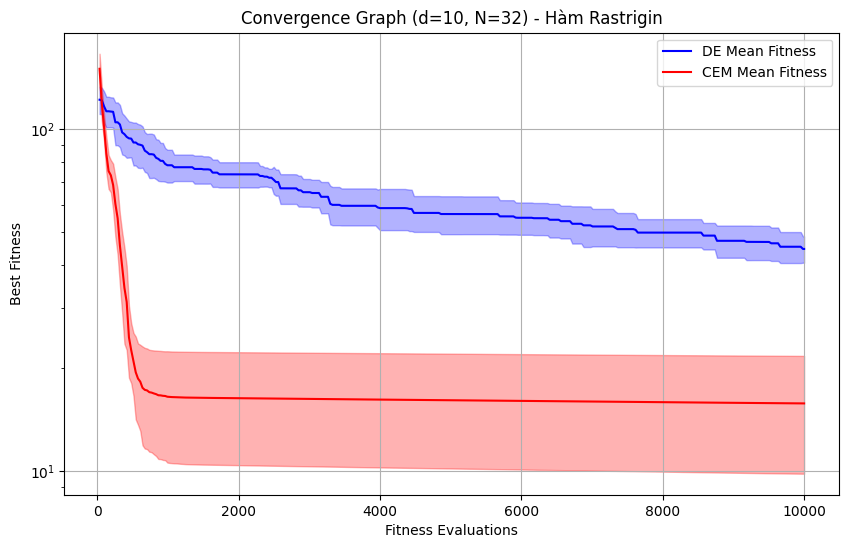

In [11]:
# Biểu đồ Convergence Graph với vùng đổ bóng độ lệch chuẩn (fill_between)
def plot_convergence(func_name, d, N):
    d_hists = convergence_data[func_name][d][N]['DE_hists']
    c_hists = convergence_data[func_name][d][N]['CEM_hists']
    
    def extract_stats(hists):
        # Do tất cả runs với số gọi hàm cố định nên kích thước array là như nhau
        evals_arr = np.array([x[0] for x in hists[0]])
        vals_arr = np.array([[x[1] for x in run_hist] for run_hist in hists])
        mean_vals = np.mean(vals_arr, axis=0)
        std_vals = np.std(vals_arr, axis=0)
        return evals_arr, mean_vals, std_vals

    de_evals, de_mean, de_std = extract_stats(d_hists)
    cem_evals, cem_mean, cem_std = extract_stats(c_hists)

    plt.figure(figsize=(10, 6))
    
    # Vẽ DE
    plt.plot(de_evals, de_mean, label='DE Mean Fitness', color='blue')
    plt.fill_between(de_evals, de_mean - de_std, de_mean + de_std, alpha=0.3, color='blue')
    
    # Vẽ CEM
    plt.plot(cem_evals, cem_mean, label='CEM Mean Fitness', color='red')
    plt.fill_between(cem_evals, cem_mean - cem_std, cem_mean + cem_std, alpha=0.3, color='red')
    
    plt.yscale('log')
    plt.title(f'Convergence Graph (d={d}, N={N}) - Hàm {func_name}')
    plt.xlabel('Fitness Evaluations')
    plt.ylabel('Best Fitness')
    plt.legend()
    plt.grid(True)
    plt.show()

# Minh họa đồ thị sử dụng các tham số 1 hàm làm ví dụ
plot_convergence('Rastrigin', d=10, N=32)


In [12]:
import os

# Tạo thư mục để chứa 10 file GIF cho gọn gàng
os.makedirs("GIF_Results", exist_ok=True)

# Sửa lại một chút hàm make_gif_animation để tên file linh hoạt hơn
def make_gif_animation_fixed(algo_name, func_name):
    d = 2
    N = 32
    max_evals = 2000
    seed = MSSV
    
    info = FUNCTIONS[func_name]
    func = info['func']
    bounds = np.array([info['bound']] * d)
    
    if algo_name == 'DE':
        _, best_hists, pop_hists = differential_evolution(func, bounds, N, max_evals, seed, return_history=True, return_pop_history=True)
    else:
        _, best_hists, pop_hists = cross_entropy_method(func, bounds, N, max_evals, seed, return_history=True, return_pop_history=True)
    
    fig, ax = plt.subplots(figsize=(6, 6))
    
    # Vẽ Contour map
    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.zeros_like(X)
    for i in range(100):
        for j in range(100):
            Z[i, j] = func(np.array([X[i, j], Y[i, j]]))
            
    CS = ax.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.6)
    
    if func_name == 'Rosenbrock':
        opt_x, opt_y = 1.0, 1.0
    else:
        opt_x, opt_y = 0.0, 0.0
    
    ax.scatter(opt_x, opt_y, marker='D', color='red', s=100, label='Global Minimum')
    scat = ax.scatter([], [], color='orange', edgecolor='black', s=40)
    ax.legend(loc='upper right')
    
    def update(frame):
        pop = pop_hists[frame]
        scat.set_offsets(pop) 
        ax.set_title(f'{algo_name} on {func_name} - Gen {frame+1}\nEvals: {best_hists[frame][0]} | Best: {best_hists[frame][1]:.4e}')
        return scat,
        
    anim = animation.FuncAnimation(fig, update, frames=len(pop_hists), interval=150, blit=True)
    
    # SỬA LẠI TÊN FILE CÓ CHỨA TÊN HÀM
    filename = f'GIF_Results/{algo_name}_{func_name}_d2_N32.gif'
    anim.save(filename, writer='pillow', fps=6)
    plt.close()
    
    return filename

# VÒNG LẶP XUẤT ĐỦ 10 FILE GIF
print("Đang tiến hành tạo 10 file GIF cho 5 hàm... (Vui lòng đợi vài phút)")
gif_paths = []
for func_name in FUNCTIONS.keys():
    print(f"  -> Đang tạo GIF cho hàm {func_name}...")
    de_gif = make_gif_animation_fixed('DE', func_name)
    cem_gif = make_gif_animation_fixed('CEM', func_name)
    gif_paths.extend([de_gif, cem_gif])

print("Đã tạo xong toàn bộ GIF! Bạn có thể tải thư mục 'GIF_Results' về và nộp bài.")

Đang tiến hành tạo 10 file GIF cho 5 hàm... (Vui lòng đợi vài phút)
  -> Đang tạo GIF cho hàm Sphere...
  -> Đang tạo GIF cho hàm Rastrigin...
  -> Đang tạo GIF cho hàm Rosenbrock...
  -> Đang tạo GIF cho hàm Ackley...
  -> Đang tạo GIF cho hàm Griewank...
Đã tạo xong toàn bộ GIF! Bạn có thể tải thư mục 'GIF_Results' về và nộp bài.


In [13]:
# Hiển thị trực tiếp hai file GIF trên notebook
display(Markdown("### DE Animation"))
display(HTML(f'<img src="{de_gif}" alt="DE" width="400">'))

display(Markdown("### CEM Animation"))
display(HTML(f'<img src="{cem_gif}" alt="CEM" width="400">'))


### DE Animation

### CEM Animation